# ANALIZA VOLILNIH OKRAJEV V REPUBLIKI SLOVENIJI
V seminarski nalogi pri predmetu UVP se bom ukvarjal s temo, ki me zelo zanima — s politiko. Ker se politologijo obravnava kot družbeno znanost, politika nasploh pa kot nekaj, kar delajo družboslovci, to odpira pomembno vprašanje, kako lahko pri tej poglavitni obrti pomaga matematika. Politične stranke in politiki svoje delovanje prilagajajo vtisu na terenu in izkušnjam iz preteklosti, a še nisem zasledil, da bi se kdo tega lotil strukturirano, analitično in podkrepljeno z matematičnimi idejami. Zato se bom v tej seminarski nalogi posvetil več ali manj enemu vprašanju: če bi vodil neko politično stranko, kateri okraji bi bili zame ključni?

POLITIČNI KONTEKST: Slovenija je razdeljena na 8 volilnih enot (Kranj, Postojna, Ljubljana Center, Ljubljana Bežigrad, Celje, Novo mesto, Maribor, Ptuj), kjer je vsaka izmed enot razdeljena na 11 volilnih okrajev (npr. Škofja Loka I, Ljubljana Vič-Rudnik III, Maribor 7 idr.) Vsaka politična stranka, ki na tekmuje na volitvah v državni zbor, v vsak okraj postavi po enega kandidata, ki stranko zastopa v tistem okolišu. Če za obseg te analize zelo poenostavimo, je poslanec izvoljen v državni zbor, če v okraju, v katerem kandidira, doseže procentualno najboljši rezultat glede na ostale kandidate iz iste stranke v volilni enoti. Seveda sistem ni tako direkten, a je logičen. Stranke svoje zveste in najbolj prepoznavne kandidate postavijo v okraje, kjer jim je izvolitev zagotovljena. Poznavanje zgodovinske podpore dotičnih okrajev v državi strankam omogoča, da si prosto sestavijo poslansko skupino. Zato je pomembno, da stranke politične okraje preučijo iz bolj matematičnega vidika in ne zgolj z občutkom in intuicijo. 

V analizi se bom osredotočal na spreminjanje politične strukture volilnih okrajev na vseh državnozvorskih volitvah v tem tisočletju (2000, 2004, 2008, 2011, 2014, 2018, 2022, 2026) ter poskušal odgovoriti na vprašanje:
**Ko postavljam svoje politične kandidate v volilne okraje, kam postavim svoje ključne igralce, ki želim, da so izvoljeni?**

V ameriški politiki so zelo uveljavljeni termini "blue state", "red state", "swing state", ki opisujejo, ali neka zvezna država načeloma tradicionalno voli demokrate ali republikance ali pa pogosto niha med njima. Nekaj takega si želim izračunati tudi sam.

In [12]:
import pandas as pd

rezultati2026 = pd.read_csv("rezultati_2026_prc.csv")
rezultati2022 = pd.read_csv("rezultati_2022_prc.csv")
rezultati2018 = pd.read_csv("rezultati_2018_prc.csv")
rezultati2014 = pd.read_csv("rezultati_2014_prc.csv")
rezultati2011 = pd.read_csv("rezultati_2011_prc.csv")
rezultati2008 = pd.read_csv("rezultati_2008_prc.csv")
rezultati2004 = pd.read_csv("rezultati_2004_prc.csv")
rezultati2000 = pd.read_csv("rezultati_2000_prc.csv")

rezultati2026_gl = pd.read_csv("rezultati_2026_gl.csv")
rezultati2022_gl = pd.read_csv("rezultati_2022_gl.csv")
rezultati2018_gl = pd.read_csv("rezultati_2018_gl.csv")
rezultati2014_gl = pd.read_csv("rezultati_2014_gl.csv")
rezultati2011_gl = pd.read_csv("rezultati_2011_gl.csv")
rezultati2008_gl = pd.read_csv("rezultati_2008_gl.csv")
rezultati2004_gl = pd.read_csv("rezultati_2004_gl.csv")
rezultati2000_gl = pd.read_csv("rezultati_2000_gl.csv")

Politične stranke so se v 26 letih, ki jih analiziramo, menjavale, spreminjale imena, vzniknile so nove stranke, kakšne pa so se upokojile. Nemogoče bi bilo utemeljiti, kateri okraj pripada določeni stranki, zato sem se omejil bolj na ideološko pripadnost strank, t.j.  ***progresivizem***, ***socialna demokracija***, ***leva sredina*** (ta je najpogosteje menjavala imena, temu oznaka konglomerat), ***sredina*** (ali stranke, ki so se predstavljali kot novi sredinski igralci), ***antisistemskost***, ***klasični konservatizem***, ***nacionalizem*** ter ***neuvrščeni*** (praktično neprepoznavne stranke).

Stranke sem v ideološke okvirje uvrstil po lastni presoji, glede na poznavanje slovenske politike in pregledovanja interneta. Samo za pojasnilo: med neuvščene sem določil stranke, ki so dosegle manj kot 1% glasov in niso jasno pripadale nobeni drugi ideologiji.

In [13]:
ideologije_klasifikacija = {
    2026: {
        "PROGRESIVCI": ["LEVICA IN VESNA", "PIRATI", "MI, SOCIALISTI!"],
        "SOC.DEM": ["SD"],
        "LEVI KONGLOMERAT": ["SVOBODA", "PREROD"],
        "NOVA SREDINA": ["DEMOKRATI."],
        "ANTISISTEM": ["RESNI.CA"],
        "KONSERVATIVCI": ["NSi, SLS, FOKUS"],
        "NACIONALISTI": ["SDS", "SNS"],
        "NEUVRŠČENI": ["ZAUPANJE", "ALTERNATIVA", "ZELENI+SG"]
    },
    2022: {
        "PROGRESIVCI": ["LEVICA", "Pirati", "VESNA"],
        "SOC.DEM": ["SD"],
        "LEVI KONGLOMERAT": ["SVOBODA", "LMŠ", "SAB", "SNP-DD"],
        "NOVA SREDINA": ["DeSUS"],
        "ANTISISTEM":["Resni.ca", "NESTRANKARSKA"],
        "KONSERVATIVCI": ["NSi", "POVEŽIMO", "NAŠA DEŽELA"],
        "NACIONALISTI": ["SDS", "SNS", "DOM"],
        "NEUVRŠČENI": ["ZLS", "L'BP"]
    },
    2018: {
        "PROGRESIVCI": ["LEVICA", "PIRATI", "SOLIDARNOST"],
        "SOC.DEM": ["SD"],
        "LEVI KONGLOMERAT": ["SMC", "LMŠ", "STRANKA AB", "DD"],
        "NOVA SREDINA": ["ZELENI", "DeSUS"],
        "ANTISISTEM": [],
        "KONSERVATIVCI": ["NSi", "SLS"],
        "NACIONALISTI": ["SDS", "SNS"],
        "NEUVRŠČENI": ["GAS", "Zsi", "LNBP", "GSN", "ZD"]
    },
    2014: {
        "PROGRESIVCI": ["ZDRUŽENA LEVICA", "PIRATSKA STRANKA"],
        "SOC.DEM": ["SD", "VERJAMEM"],
        "LEVI KONGLOMERAT": ["SMC", "PS"],
        "NOVA SREDINA": ["ZAAB", "DeSUS", "DL"],
        "ANTISISTEM": [],
        "KONSERVATIVCI": ["NSi", "SLS"],
        "NACIONALISTI": ["SDS", "SNS"],
        "NEUVRŠČENI": ["LGS", "HS", "ED - NPS", "ZELENI"]
    },
    2011: {
        "PROGRESIVCI": ["TRS", "Humana", "SEM-Si"],
        "SOC.DEM": ["SD"],
        "LEVI KONGLOMERAT": ["LZJ - PS", "LDS"],
        "NOVA SREDINA": ["LGV", "DeSUS"],
        "ANTISISTEM": [],
        "KONSERVATIVCI": ["NSi", "SLS"],
        "NACIONALISTI": ["SDS", "SNS"],
        "NEUVRŠČENI": [
            "Akacije",
            "DSD",
            "SSN",
            "NPS",
            "SMS Zeleni",
            "ZARES",
            "Zeleni",
            "GZS",
        ]
    },

    2008: {
        "PROGRESIVCI": ["LZ�PV", "LPR", "ZP"],
        "SOC.DEM": ["SD"],
        "LEVI KONGLOMERAT": ["ZARES", "LDS"],
        "NOVA SREDINA": ["DeSUS"],
        "ANTISISTEM": [],
        "KONSERVATIVCI": ["NSi", "SLS+SMS", "KDS"],
        "NACIONALISTI": ["SDS", "SNS", "Lipa"],
        "NEUVRŠČENI": ["Akacije", "NPS", "SSN", "Zeleni"]
    },

    2004: {
        "PROGRESIVCI": ["JL", "SEG", "SMS", "ZELENI"],
                "SOC.DEM": ["ZLSD"],
                "LEVI KONGLOMERAT": ["AS", "LDS"],
                "NOVA SREDINA": ["DeSUS"],
                "ANTISISTEM": ["SJN"],
                "KONSERVATIVCI": ["NSi", "SLS"],
                "NACIONALISTI": ["SDS", "SNS"],
                "NEUVRŠČENI": ["DSS", "GŽZ, ZZP, ZNS, NDS", "NPS", "SSN", "LS", "ZAPS", "ZDRUŽENI", "MARKO BRECELJ","MIHAEL SVANJAK","ŠTEFAN HUDOBIVNIK"]
    },
    2000: {
        "PROGRESIVCI": ["ZDRUŽENI ZELENI", "SMS"],
        "SOC.DEM": ["ZLSD"],
        "LEVI KONGLOMERAT": ["LDS"],
        "NOVA SREDINA": ["DeSUS"],
        "ANTISISTEM": [],
        "KONSERVATIVCI": ["SLS+SKD", "NSi"],
        "NACIONALISTI": ["SDS", "SNS"],
        "NEUVRŠČENI": ["NOVA", "DS"]
    }
    }

ideologije = list(ideologije_klasifikacija[2000].keys())

In [14]:
rezultati_po_letih = {
    2026: rezultati2026,
    2022: rezultati2022,
    2018: rezultati2018,
    2014: rezultati2014,
    2011: rezultati2011,
    2008: rezultati2008,
    2004: rezultati2004,
    2000: rezultati2000
}

rezultati_po_letih_gl = {
    2026: rezultati2026_gl,
    2022: rezultati2022_gl,
    2018: rezultati2018_gl,
    2014: rezultati2014_gl,
    2011: rezultati2011_gl,
    2008: rezultati2008_gl,
    2004: rezultati2004_gl,
    2000: rezultati2000_gl
}

for leto, tabela in rezultati_po_letih.items():
    for ideologija, stranke in ideologije_klasifikacija[leto].items():
        tabela[ideologija] = tabela[stranke].sum(axis=1)

for leto, tabela in rezultati_po_letih_gl.items():
    for ideologija, stranke in ideologije_klasifikacija[leto].items():
        tabela[ideologija] = tabela[stranke].sum(axis=1)


rezultati_2026_koncni = rezultati2026[['OKRAJ', 'PROGRESIVCI', 'SOC.DEM','LEVI KONGLOMERAT','NOVA SREDINA', 'ANTISISTEM','KONSERVATIVCI','NACIONALISTI','NEUVRŠČENI']]
rezultati_2022_koncni = rezultati2022[['OKRAJ', 'PROGRESIVCI', 'SOC.DEM','LEVI KONGLOMERAT','NOVA SREDINA', 'ANTISISTEM','KONSERVATIVCI','NACIONALISTI','NEUVRŠČENI']]
rezultati_2018_koncni = rezultati2018[['OKRAJ', 'PROGRESIVCI', 'SOC.DEM','LEVI KONGLOMERAT','NOVA SREDINA', 'ANTISISTEM','KONSERVATIVCI','NACIONALISTI','NEUVRŠČENI']]
rezultati_2014_koncni = rezultati2014[['OKRAJ', 'PROGRESIVCI', 'SOC.DEM','LEVI KONGLOMERAT','NOVA SREDINA', 'ANTISISTEM','KONSERVATIVCI','NACIONALISTI','NEUVRŠČENI']]
rezultati_2011_koncni = rezultati2011[['OKRAJ', 'PROGRESIVCI', 'SOC.DEM','LEVI KONGLOMERAT','NOVA SREDINA', 'ANTISISTEM','KONSERVATIVCI','NACIONALISTI','NEUVRŠČENI']]
rezultati_2008_koncni = rezultati2008[['OKRAJ', 'PROGRESIVCI', 'SOC.DEM','LEVI KONGLOMERAT','NOVA SREDINA', 'ANTISISTEM','KONSERVATIVCI','NACIONALISTI','NEUVRŠČENI']]
rezultati_2004_koncni = rezultati2004[['OKRAJ', 'PROGRESIVCI', 'SOC.DEM','LEVI KONGLOMERAT','NOVA SREDINA', 'ANTISISTEM','KONSERVATIVCI','NACIONALISTI','NEUVRŠČENI']]
rezultati_2000_koncni = rezultati2000[['OKRAJ', 'PROGRESIVCI', 'SOC.DEM','LEVI KONGLOMERAT','NOVA SREDINA', 'ANTISISTEM','KONSERVATIVCI','NACIONALISTI','NEUVRŠČENI']]

rezultati_2026_koncni_gl = rezultati2026_gl[['OKRAJ', 'PROGRESIVCI', 'SOC.DEM','LEVI KONGLOMERAT','NOVA SREDINA', 'ANTISISTEM','KONSERVATIVCI','NACIONALISTI','NEUVRŠČENI']]
rezultati_2022_koncni_gl = rezultati2022_gl[['OKRAJ', 'PROGRESIVCI', 'SOC.DEM','LEVI KONGLOMERAT','NOVA SREDINA', 'ANTISISTEM','KONSERVATIVCI','NACIONALISTI','NEUVRŠČENI']]
rezultati_2018_koncni_gl = rezultati2018_gl[['OKRAJ', 'PROGRESIVCI', 'SOC.DEM','LEVI KONGLOMERAT','NOVA SREDINA', 'ANTISISTEM','KONSERVATIVCI','NACIONALISTI','NEUVRŠČENI']]
rezultati_2014_koncni_gl = rezultati2014_gl[['OKRAJ', 'PROGRESIVCI', 'SOC.DEM','LEVI KONGLOMERAT','NOVA SREDINA', 'ANTISISTEM','KONSERVATIVCI','NACIONALISTI','NEUVRŠČENI']]
rezultati_2011_koncni_gl = rezultati2011_gl[['OKRAJ', 'PROGRESIVCI', 'SOC.DEM','LEVI KONGLOMERAT','NOVA SREDINA', 'ANTISISTEM','KONSERVATIVCI','NACIONALISTI','NEUVRŠČENI']]
rezultati_2008_koncni_gl = rezultati2008_gl[['OKRAJ', 'PROGRESIVCI', 'SOC.DEM','LEVI KONGLOMERAT','NOVA SREDINA', 'ANTISISTEM','KONSERVATIVCI','NACIONALISTI','NEUVRŠČENI']]
rezultati_2004_koncni_gl = rezultati2004_gl[['OKRAJ', 'PROGRESIVCI', 'SOC.DEM','LEVI KONGLOMERAT','NOVA SREDINA', 'ANTISISTEM','KONSERVATIVCI','NACIONALISTI','NEUVRŠČENI']]
rezultati_2000_koncni_gl = rezultati2000_gl[['OKRAJ', 'PROGRESIVCI', 'SOC.DEM','LEVI KONGLOMERAT','NOVA SREDINA', 'ANTISISTEM','KONSERVATIVCI','NACIONALISTI','NEUVRŠČENI']]

rezultati_2026_koncni.insert(0, 'LETO', 2026)
rezultati_2022_koncni.insert(0, 'LETO', 2022)
rezultati_2018_koncni.insert(0, 'LETO', 2018)
rezultati_2014_koncni.insert(0, 'LETO', 2014)
rezultati_2011_koncni.insert(0, 'LETO', 2011)
rezultati_2008_koncni.insert(0, 'LETO', 2008)
rezultati_2004_koncni.insert(0, 'LETO', 2004)
rezultati_2000_koncni.insert(0, 'LETO', 2000)

rezultati_2026_koncni_gl.insert(0, 'LETO', 2026)
rezultati_2022_koncni_gl.insert(0, 'LETO', 2022)
rezultati_2018_koncni_gl.insert(0, 'LETO', 2018)
rezultati_2014_koncni_gl.insert(0, 'LETO', 2014)
rezultati_2011_koncni_gl.insert(0, 'LETO', 2011)
rezultati_2008_koncni_gl.insert(0, 'LETO', 2008)
rezultati_2004_koncni_gl.insert(0, 'LETO', 2004)
rezultati_2000_koncni_gl.insert(0, 'LETO', 2000)

df_all = pd.concat([
    rezultati_2026_koncni,
rezultati_2022_koncni,
rezultati_2018_koncni,
rezultati_2014_koncni,
rezultati_2011_koncni,
rezultati_2008_koncni,
rezultati_2004_koncni,
rezultati_2000_koncni
])

df_all_gl = pd.concat([
    rezultati_2026_koncni_gl,
rezultati_2022_koncni_gl,
rezultati_2018_koncni_gl,
rezultati_2014_koncni_gl,
rezultati_2011_koncni_gl,
rezultati_2008_koncni_gl,
rezultati_2004_koncni_gl,
rezultati_2000_koncni_gl
])

In [15]:
# tabela z vsemi rezultati (v deležih in glasovih) po okraju, letu in ideologiji 
df_all
df_all_gl

,LETO,OKRAJ,PROGRESIVCI,SOC.DEM,LEVI KONGLOMERAT,NOVA SREDINA,ANTISISTEM,KONSERVATIVCI,NACIONALISTI,NEUVRŠČENI
0,2026,1001,1375,899,6717,757,1512.0,933,3784,189
1,2026,1002,980,530,2994,655,557.0,932,2971,117
2,2026,1003,1211,644,3503,1020,874.0,1076,3030,136
3,2026,1004,1557,790,4605,999,1356.0,1076,3512,165
4,2026,1005,1501,757,4444,890,1698.0,1497,3675,168
...,...,...,...,...,...,...,...,...,...,...
83,2000,8007,267,621,2084,251,0.0,2882,1416,238
84,2000,8008,384,629,2378,939,0.0,1857,1811,196
85,2000,8009,520,592,2968,609,0.0,3545,3535,142
86,2000,8010,598,1136,4532,650,0.0,1291,3060,113


Številke nam povejo veliko, a grafični prikazi so najbolj berljivi in nazorni, zato bom konstruiral funkcijo, ki kot argument vzame šifro okraja in vrne graf, ki prikazuje višino podpore različnih ideologij v okraju skozi 26 let.

In [16]:
import matplotlib.pyplot as plt

def okraj_skozi_leta(okraj):
    '''Funkcija, ki vrne prikaz ideologij v nekem okraju skozi leta'''
    
    okraj_skozi_leta = (
    df_all[df_all["OKRAJ"] == okraj]
    .set_index("LETO")
    [ideologije]
    .sort_index()
    )

    okraj_skozi_leta.plot(
        kind="line",
        marker="o",
        figsize=(12, 6),
        color = ['#f50505', '#b00e0e', '#0707f0', '#131378', '#f507c1', '#5e3b18', '#000000', '#f2fa0f'],

    )

    plt.title(f"Spremembe razmerij moči v okraju {okraj} skozi leta")
    plt.xlabel("Leto")
    plt.ylabel("Delež glasov")
    plt.ylim(0, 0.55)
    plt.grid(True, alpha=0.3)
    plt.legend(title="Ideologija", bbox_to_anchor=(1.22, 1), loc="upper right")
    return plt.show()


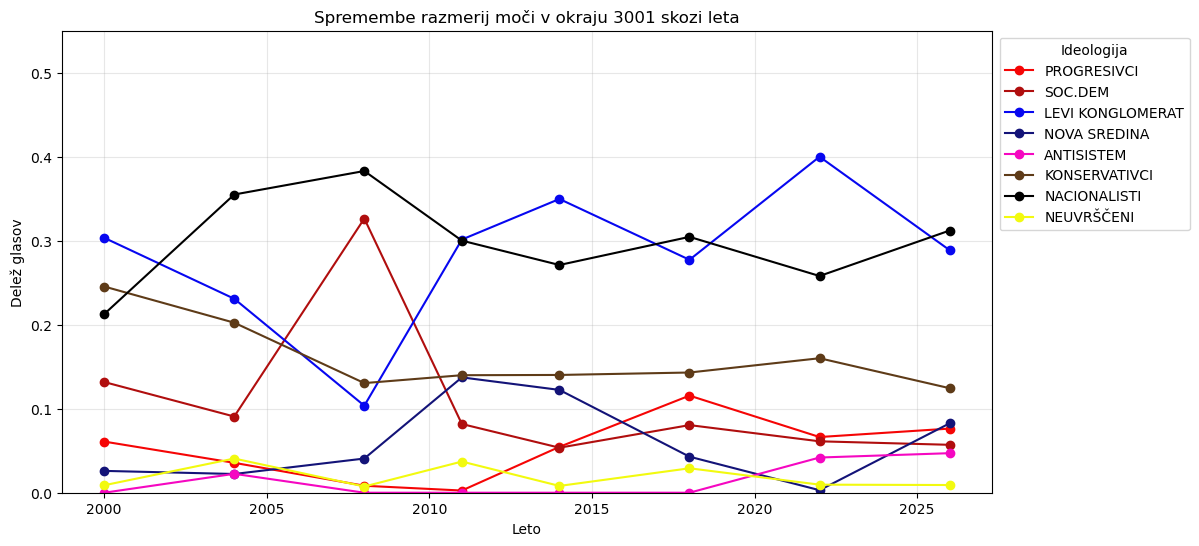

In [17]:
okraj_skozi_leta(3001)

### KATERI SO NAJBOLJ SWING OKRAJI?
S pomočjo računanja STD za vsak okraj na dolgi rok (kako se je vsaka ideologija spreminjala skozi čas) lahko izačunamo, kateri okraj ima najvišjo povprečno STD in na podlagi tega okraj uvrstimo med swing okraje. Tudi nasploh bo STD skozi leta pomemben za klasifikacijo okrajev kot trdna volilna baza ali trend zadnjih let.

In [18]:
std_po_okrajih = df_all.groupby('OKRAJ')[ideologije].std()
std_po_okrajih['average_temporal_STD'] = std_po_okrajih.mean(axis=1)
std_po_okrajih.sort_values('average_temporal_STD', ascending=False)['average_temporal_STD']

OKRAJ
2004    0.067761
2005    0.066194
2010    0.064152
4006    0.062621
3007    0.062310
          ...   
6008    0.042155
4003    0.041742
4002    0.041238
7003    0.040923
5006    0.040716
Name: average_temporal_STD, Length: 88, dtype: float64

Vidimo, da je najbolj nekonsistenten okraj, kjer se razmerja moči najbolj spreminjajo skozi leto, okraj 2004 — Koper I, ki obsega centralni del Kopra. Na drugem koncu spektra pa imamo okraj 5006 — Mozirje, kjer naj bi bila razmerja moči skozi zadnjih 26 let najbolj stabilna. Razlika med Koprom I in Mozirjem je izrazito očitna, ko razmerja uprizorimo grafično.

Pedersenov indeks je v politični analizi merilo za premikanje volivcev med strankami med dvema zaporednima volitvami. Gre za merilo, ki jo znanstveno dokumentirano in je pogosteje uporabeljno kot standardna deviacija. Ker se na področje ne spoznam, bom uporabil obe merili in videl, ali je kakšna očitna razlika med obema rezultatoma. Pedersenov indeks se izračuna kot polovico vsote razlike med rezultati stranke na dveh zaporednih volitvah, pri čemer seštejemo vse stranke. Za vsak okraj sem izračunal povprečje Pedersonovega indeksa med volitvami

In [19]:
# PEDERSON'S INDEX
df_spremembe = df_all.sort_values(['LETO', 'OKRAJ']).copy()
df_spremembe[ideologije] = (abs(
    df_spremembe
    .groupby("OKRAJ")[ideologije]
    .diff())
)
df_spremembe["PEDERSON INDEX"] = 1/2*df_spremembe[ideologije].sum(axis=1)
df_spremembe.set_index(['OKRAJ','LETO'])
df_spremembe_koncna = df_spremembe[['LETO', 'OKRAJ', 'PEDERSON INDEX']].set_index(['OKRAJ', 'LETO']).sort_values('OKRAJ')
df_pederson_index = df_spremembe_koncna.groupby(level="OKRAJ").mean()*(8/7) # z 8/7 množim, ker je v resnici 7 sprememb med volitvami, mean pa je upošteval 8
df_pederson_index.sort_values('PEDERSON INDEX', ascending=False)

,PEDERSON INDEX
OKRAJ,
2004,0.266076
2005,0.260253
4006,0.251259
2010,0.249958
3008,0.239104
...,...
8007,0.165173
4001,0.163627
1009,0.162551


Vidimo, da je nekaj razlik med rezultati Pedersonovega indeksa in standardne deviacije med rezultati na volitvah, a najbolj in najmanj "swing" okraj sta ostala enaka, torej Koper I in Mozirje.

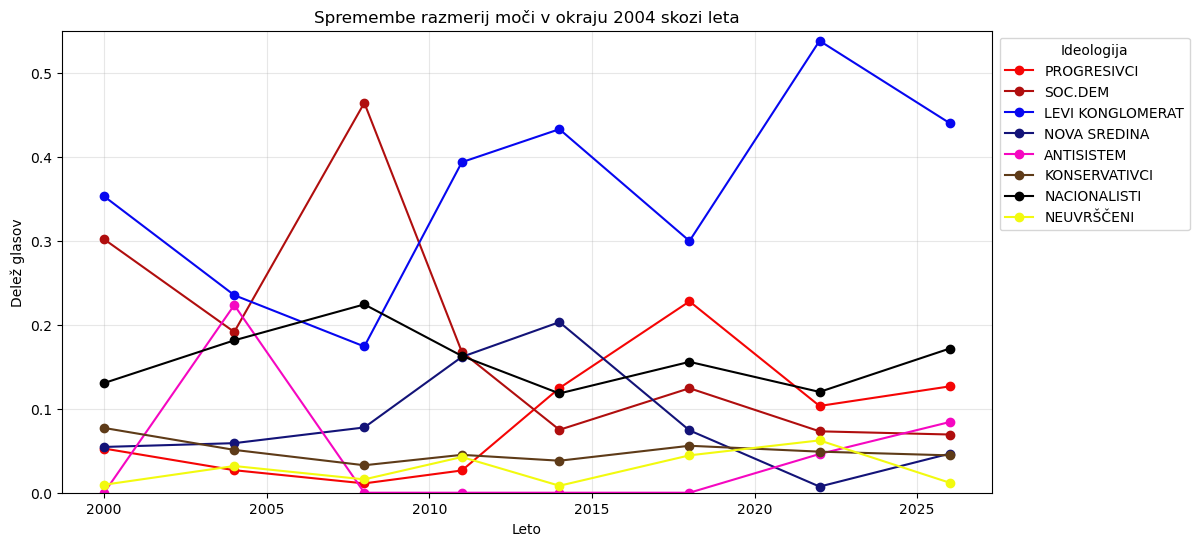

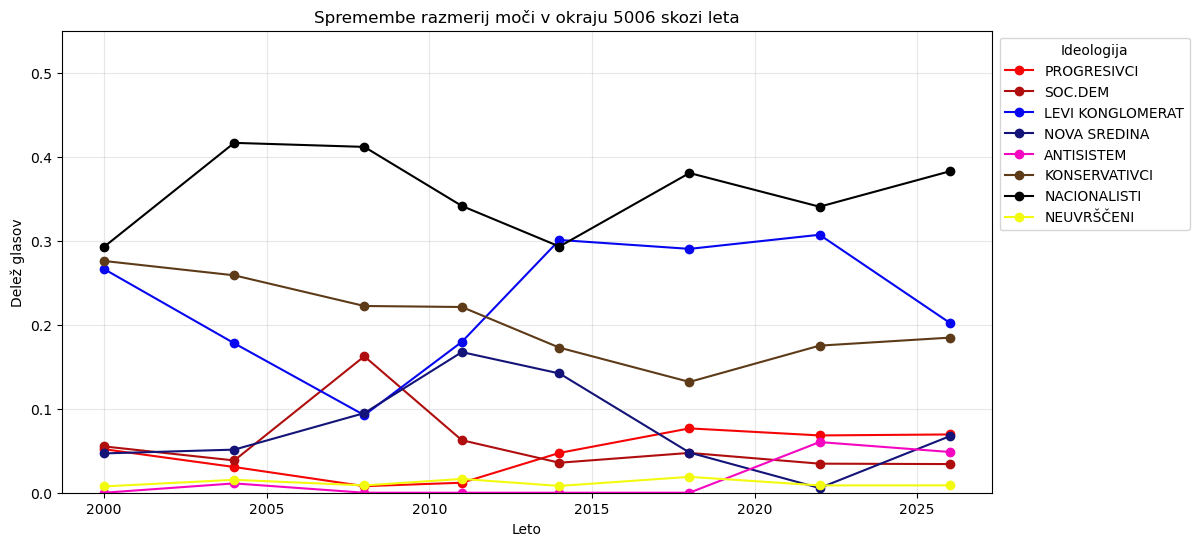

In [20]:
okraj_skozi_leta(2004) # prikaz Kopra I
okraj_skozi_leta(5006) # prikaz Mozirja

### POVPREČNI REZULTATI IDEOLOGIJ PO OKRAJIH V ČASU 2000—

Radi bi za nek splošen vtis preverili, v katerem okraju ima vsaka ideologija najvišjo povprečno vrednost odstotkov glasov skozi leta. Čeprav to ne pokaže celotne slike, je zanimiv izračun. 

In [21]:
df_average = df_all.groupby('OKRAJ')[ideologije].mean()
district_maxxing = df_average.idxmax()
district_maxxing 

PROGRESIVCI         3007
SOC.DEM             4001
LEVI KONGLOMERAT    6011
NOVA SREDINA        8003
ANTISISTEM          2004
KONSERVATIVCI       1009
NACIONALISTI        4003
NEUVRŠČENI          2011
dtype: int64

Za komentar zunanjemu opazovalcu: očitno imajo progresivci v povprečju najvišji povprečni rezultat v okraju Ljubljana Center, Socialni Demokrati (ki so skoraj v celoti zastopani z barvami stranke SD) v okraju Kočevje, mainstream leva sredina v okraju Zagorje, t. i. (nova) sredina, ki lahko glasove prispeva tako levo kot desno, v okraju Ljutomer, antisistemske stranke so v povprečju največ glasov dobile v Kopru I*, konservativci v Škofji Loki II, nacionalisti v Grosuplju (domači okraj Janeza Janše), neuvrščeni (stranke brez izrazite politične pripadnosti z manj kot 1% glasov) pa v kraju Ajdovščina. 

\* vredno je pripomniti, da je kot smo ugotovili zgoraj, Koper I najbolj nestanoviten politični okraj v Sloveniji, zato niti ni presentljivo, da antisistemske stranke v njem uspevajo. Leta 2008 je stranka Slovenija je naša (pod vodstvom takratnega koprskega župana Borisa Popoviča) požela enormen uspeh v Kopru, in ta uspeh močno dviguje povprečno vrednost antistemskim strankam v Kopru I, čeprav je kontekst predstavnika stranke v domačem okolju nezanemraljiv. Vseeno je antisistemska stranka Resni.Ca v letu 2026 v Kopru I dosegla 8,41%, kar je bil njen 5. najboljši rezultat v Sloveniji, zato povprečje antisistemskih strank v Kopru I nakazuje na nek trend. 

## DETAJLIRANA ANALIZA OKRAJEV ZA SOCIALNE DEMOKRATE in KONSERVATIVCE

V nadaljevanju analize se bom osredotočil na dve izmed najbolj dolgoživih ideologij v kontekstu politične zgodovine na Slovenskem, ki pa se v zadnjih letih soočata z izzivi polarizacije in posledičnem odtekanjem volivcev k bolj polarnim strankam.
DISCLAIMER: izbira ideologij, na katere se bom osredotočil, je posledica razmisleka, da se je njihova zastopanost skozi leta najmanj spreminjala, saj so socialno demokracijo od samega začetka zastopali skoraj izključno stranka SD (prej ZLSD), konservativce pa Nova Slovenija in SLS (prej skupaj kot SKD). Najtežje bi bilo denimo analizirati antisistemske stranke, saj gre za ideologijo, ki je enormen 'umbrella term', saj antisistemske stranke obstajajo na obeh straneh političnega spektra, zato je o njih napisati kaj trdnega.
 Z izbiro ideologij ne želim politično obarvati seminarske naloge, ampak ustvariti okolje za plodovito analizo, ki bi lahko imela uporabnost v resničnem političnem kontekstu. 

### Določitev tradicionalne baze

V razmisleku v prejšnjem razdelku sem izpostavil, da samo merilo povprečnega rezultata v nekem okraju preprosto ni dovolj, da nek okraj določimo kot volilno bazo neke ideologije, saj lahko nek dober rezultat (naprimer izjemen rezultat socialne demokracije v letu 2008 pri nekaj več kot 31% izkrivi oziroma zamegli sliko po letu 2008, saj se izrazita nihanja ne bi poznala tako občutno na sami povprečni vrednosti). 
Za določitev najboljših tradicionalnih baz neke ideologije se bomo osredotočili na dva kriterija v tem vrstnem redu:
- visoka z-vrednost (glede na povprečje v obdobju 2000—2026), ki jo podaja enačba $z_{value} = \frac{m_i - M}{σ}$, kjer je $m_i$ povprečna vrednost ideologije v okraju, $M$ povprečna vrednost ideologije v Sloveniji, $σ$ pa STD ideologije v celotni Sloveniji
- nizka standardna deviacija ideologije v okraju skozi leta -- konsistenti rezultati ideologije v okraju skozi vseh 8 volitev od leta 2000 naprej 



In [22]:
df_average['KONSERVATIVCI_z'] = (df_average['KONSERVATIVCI']-df_average['KONSERVATIVCI'].mean())/df_average['KONSERVATIVCI'].std(ddof=0)
df_average['SOC.DEM_z'] = (df_average['SOC.DEM']-df_average['SOC.DEM'].mean())/df_average['SOC.DEM'].std(ddof=0)
df_average['SOC.DEM_STD'] = std_po_okrajih['SOC.DEM']
df_average['KONSERVATIVCI_STD'] = std_po_okrajih['KONSERVATIVCI']
df_sd = df_average[['SOC.DEM_STD','SOC.DEM_z', 'SOC.DEM']]
df_con = df_average[['KONSERVATIVCI_STD',  'KONSERVATIVCI_z', 'KONSERVATIVCI']]

In [23]:
df_sd['STD_percentile']=(-1*df_sd['SOC.DEM_STD']).rank(pct=True) # pomnožil sem z -1, ker želim najnižji STD kot največji procentil, saj bo tako najlažje računati naprej
df_sd['z_percentile']=df_sd['SOC.DEM_z'].rank(pct=True)
df_sd['score']= df_sd['z_percentile']*df_sd['STD_percentile']
df_sd.sort_values('SOC.DEM_z', ascending=False)[:10]

C:\Users\Uporabnik\AppData\Local\Temp\ipykernel_13380\663278248.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sd['STD_percentile']=(-1*df_sd['SOC.DEM_STD']).rank(pct=True) # pomnožil sem z -1, ker želim najnižji STD kot največji procentil, saj bo tako najlažje računati naprej
C:\Users\Uporabnik\AppData\Local\Temp\ipykernel_13380\663278248.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sd['z_percentile']=df_sd['SOC.DEM_z'].rank(pct=True)
C:\Users\Uporabnik\AppData\Local\Temp\ipykernel_13380\

,SOC.DEM_STD,SOC.DEM_z,SOC.DEM,STD_percentile,z_percentile,score
OKRAJ,,,,,,
4001,0.120059,2.950556,0.225785,0.125000,1.000000,0.125000
2010,0.155407,2.773570,0.219292,0.011364,0.988636,0.011235
6008,0.077993,2.385354,0.205048,0.545455,0.977273,0.533058
2002,0.115124,2.167745,0.197064,0.159091,0.965909,0.153667
2003,0.134004,2.167135,0.197041,0.056818,0.954545,0.054236
5007,0.081036,1.824976,0.184487,0.488636,0.943182,0.460873
2004,0.138119,1.792965,0.183313,0.045455,0.931818,0.042355
1011,0.085891,1.422931,0.169736,0.375000,0.920455,0.345170
2009,0.106903,1.245847,0.163239,0.193182,0.909091,0.175620


V zgornji tabeli lahko vidimo 10 okrajev socialne demokracije, kjer so v povprečju imeli najvišje procentualne rezultate. Ker pa izrazito visok SDja leta 2008 izkrivlja sliko v nekaterih okrajih (npr. Nova Gorica, kjer nas novejša zgodovina uči, da tam SD ni več tako močen — letos so tam denimo priigrali podpovprečen rezultat, čeprav jih ta tabela uvršča v sam vrh), je nujno pogledati tudi, kako trdni so tako visoki rezultati v teh okrajih. Zato bomo rezultate vizualizirali s scatter diagramom.

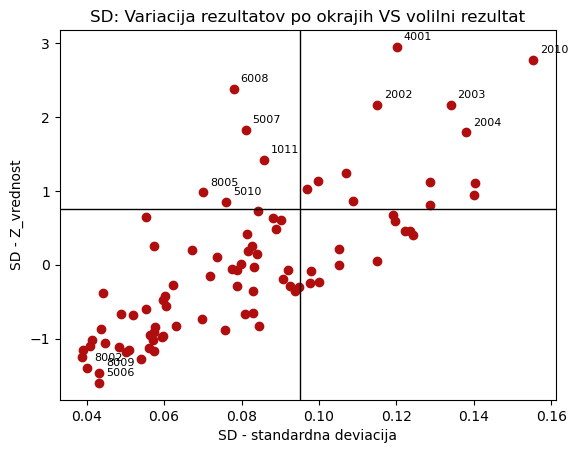

In [24]:
plt.scatter(df_sd["SOC.DEM_STD"], df_sd["SOC.DEM_z"], c='#b00e0e')

# diagram bi rad razdelil v štiri kvadrante, ki bodo imeli praktični namen
plt.axhline(0.75, color="black", linewidth=1)
plt.axvline(0.095, color="black", linewidth=1)
plt.xlabel("SD - standardna deviacija")
plt.ylabel("SD - Z_vrednost")
plt.title("SD: Variacija rezultatov po okrajih VS volilni rezultat")


# rad bi intentificiral okraje v drugem kvadrantu, tako da piše njihova šifra. Pri tem sem si pomagal izključno z AI, ker presega moje znanje pandasa, ampak so tej podatki res uporabni:
for i in range(len(df_sd)):
    x = df_sd["SOC.DEM_STD"].iloc[i]
    y = df_sd["SOC.DEM_z"].iloc[i]
    label = df_sd.index[i]

    if x < 0.095 and y > 0.75 or x > 0.1 and y > 1.5 or y<-1.3 and x < 0.05:
        plt.annotate(
            label,
            (x, y),
            textcoords="offset points",
            xytext=(5, 5),
            fontsize=8
        )

plt.show()

Ta diagram pove praktično vse, kar nas na prvi pogled zanima o rezultatih socialne demokracije v Sloveniji. Diagram smo razdelili na štiri kvadrante:
- Q1: high risk, high reward
- Q2: low risk, high reward
- Q3: low risk, no reward
- Q4: high risk, low reward

Več kot očitno je, da bi za SOC.DEM bazo razglasili okraje v kvadrantu Q2, torej zagotovljen visok rezultat, pri čemer visok rezultat vrednotimo rahlo bolj kot standradno deviacijo. Po tem merilu so za socialno demokracijo najboljši okraji po tem vrstnem redu:
1. 6008 — Kočevje
2. 5007 — Velenje I
3. 1011 — Idrija
4. 8005 — Murska Sobota II
5. 5010 — Ravne na Koroškem

Če si ogledamo trend socialne demokracije v okrajih 1011, 8005, 5010, vidimo, da rezultati nekoliko upadajo, kar nakazuje na to, da bi morali predstavniki ideologije več napora vložiti v ohranjanje svoje baze tam.


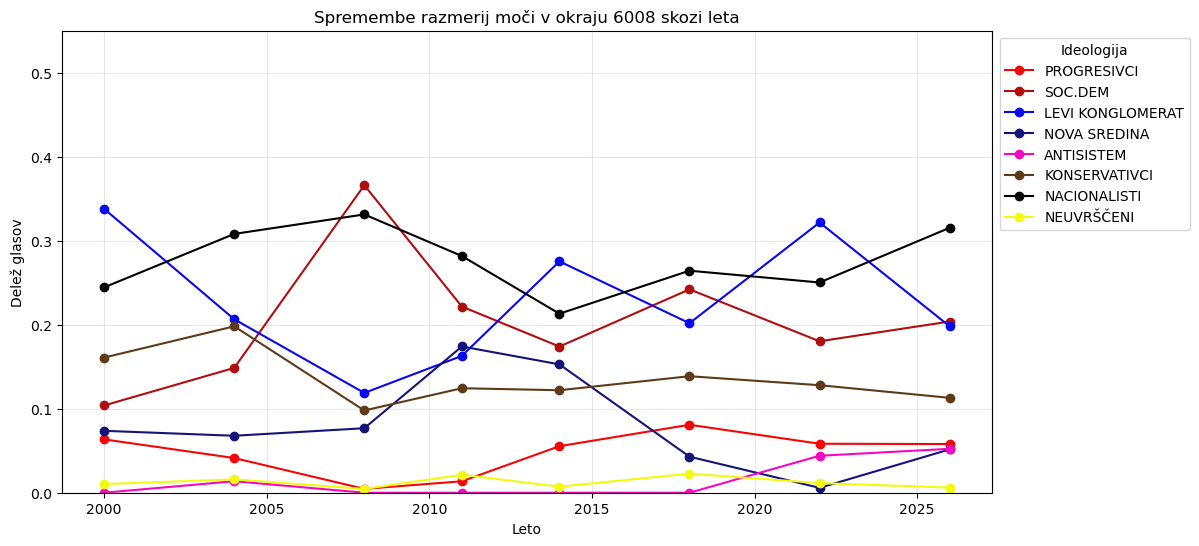

In [25]:
#najboljši okraj za socialno demokracijo (Kočevje) v diagramu skozi leta:
okraj_skozi_leta(6008)

Zdaj bomo podobno analizo opravili še za konservativce.

In [26]:
df_con['STD_percentile']=(-1*df_con['KONSERVATIVCI_STD']).rank(pct=True) # pomnožil sem z -1, ker želim najnižji STD kot največji procentil, saj bo tako najlažje računati naprej
df_con['z_percentile']=df_con['KONSERVATIVCI_z'].rank(pct=True)
df_con['score']= df_con['z_percentile']*df_con['STD_percentile']
df_con.sort_values('KONSERVATIVCI_z', ascending=False)

C:\Users\Uporabnik\AppData\Local\Temp\ipykernel_13380\656945408.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_con['STD_percentile']=(-1*df_con['KONSERVATIVCI_STD']).rank(pct=True) # pomnožil sem z -1, ker želim najnižji STD kot največji procentil, saj bo tako najlažje računati naprej
C:\Users\Uporabnik\AppData\Local\Temp\ipykernel_13380\656945408.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_con['z_percentile']=df_con['KONSERVATIVCI_z'].rank(pct=True)
C:\Users\Uporabnik\AppData\Local\Temp\

,KONSERVATIVCI_STD,KONSERVATIVCI_z,KONSERVATIVCI,STD_percentile,z_percentile,score
OKRAJ,,,,,,
1009,0.074596,2.402634,0.227814,0.068182,1.000000,0.068182
5006,0.048070,1.910125,0.205303,0.340909,0.988636,0.337035
8001,0.071018,1.905372,0.205086,0.090909,0.977273,0.088843
6007,0.083085,1.852652,0.202676,0.056818,0.965909,0.054881
8002,0.118423,1.740788,0.197564,0.011364,0.954545,0.010847
...,...,...,...,...,...,...
2002,0.024365,-1.300489,0.058559,0.818182,0.056818,0.046488
4006,0.015001,-1.394333,0.054270,0.988636,0.045455,0.044938
2003,0.020431,-1.469731,0.050824,0.909091,0.034091,0.030992


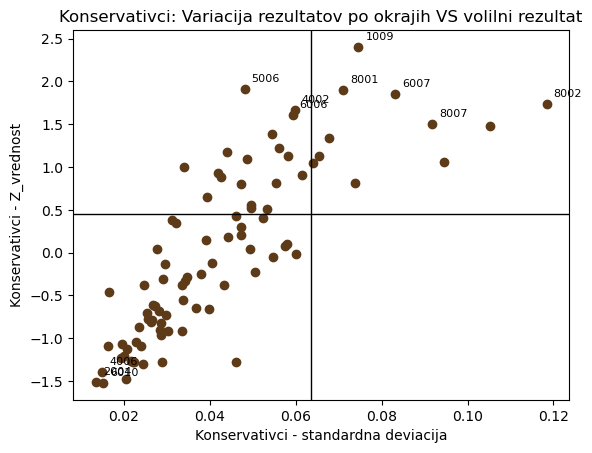

In [27]:
plt.scatter(df_con["KONSERVATIVCI_STD"], df_con["KONSERVATIVCI_z"], c='#5e3b18')

# diagram bi rad razdelil v štiri kvadrante, ki bodo imeli praktični namen
plt.axhline(0.45, color="black", linewidth=1)
plt.axvline(0.0635, color="black", linewidth=1)
plt.xlabel("Konservativci - standardna deviacija")
plt.ylabel("Konservativci - Z_vrednost")
plt.title("Konservativci: Variacija rezultatov po okrajih VS volilni rezultat")


# rad bi intentificiral okraje v drugem kvadrantu, tako da piše njihova šifra. Pri tem sem si pomagal izključno z AI, ker presega moje znanje pandasa, ampak so tej podatki res uporabni:
for i in range(len(df_con)):
    x = df_con["KONSERVATIVCI_STD"].iloc[i]
    y = df_con["KONSERVATIVCI_z"].iloc[i]
    label = df_con.index[i]

    if y>1.5 or x<0.018 and y<-1.3:
        plt.annotate(
            label,
            (x, y),
            textcoords="offset points",
            xytext=(5, 5),
            fontsize=8
        )

plt.show()

Določiti najbolj trden okraj za konservativce iz tega grafa je bistveno težje. Po eni strani ni noben okraj z daleč najboljšim povprečnim rezultatom kot okraj 1009 — Škofja Loka II, a je po drugi strani to okraj z nekoliko višjo standardno deviacijo, torej manj trden za konservativno bazo kot kakšen 5006 — Mozirje. Vseeno sem po lastni presoji ocenil, da so najboljši okraji sledeči:
1. 1009 — Škofja Loka II
2. 5006 — Mozirje
3. 4002 — Ribnica-Dobrepolje 
4. 6006 — Krško
5. 8001 — Lendava

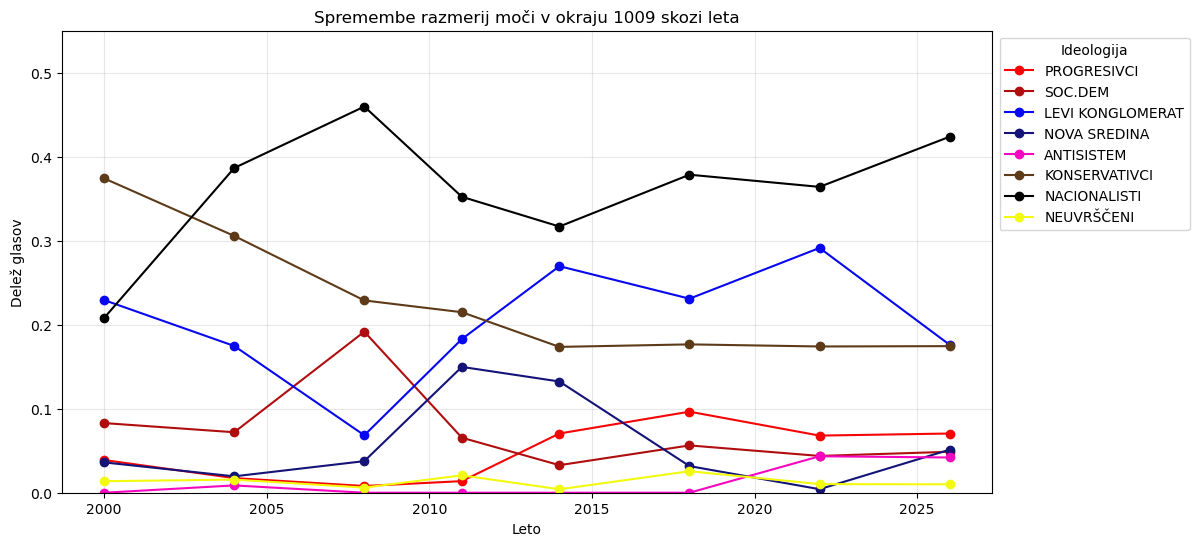

In [28]:
# najboljši okrja za konservativce
okraj_skozi_leta(1009)

Zanimivo bi bilo videti, kako ideologiji tekmujeta med seboj v različnih okrajih, zato bomo primerjali povprečne rezultate konservativcev in socialnih demokratov. 

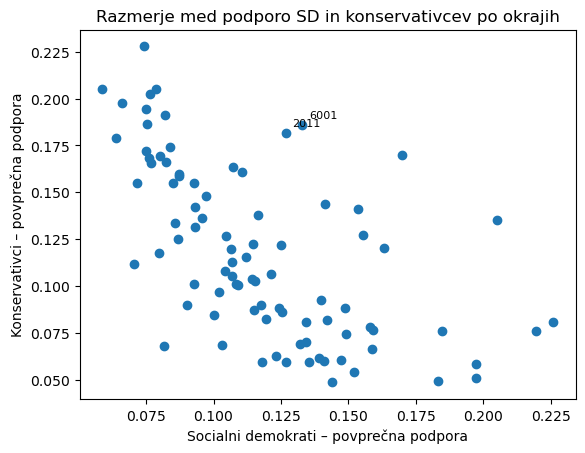

In [29]:
plt.scatter(df_average["SOC.DEM"], df_average["KONSERVATIVCI"])

plt.xlabel("Socialni demokrati – povprečna podpora")
plt.ylabel("Konservativci – povprečna podpora")
plt.title("Razmerje med podporo SD in konservativcev po okrajih")

for i in range(len(df_con)):
    y = df_average["KONSERVATIVCI"].iloc[i]
    x = df_average["SOC.DEM"].iloc[i]
    label = df_con.index[i]

    if y>0.175 and x > 0.1:
        plt.annotate(
            label,
            (x, y),
            textcoords="offset points",
            xytext=(5, 5),
            fontsize=8
        )

Vidimo lahko kar močno negativno korelacijo med konservativci in socialnimi demokrati, a opazimo tudi, da obstaja nekaj okrajev, kjer sta "močni" obe ideologiji, predvsem 2011 — Ajdovščina in 6001 — Črnomelj.

Glede na to, da veliko volivcev meni, da so konservativci in nacionalisti dve plati istega kovanca, bi rad preveril korelacijo med rezultati obeh ideologij. Enako bom storil še za progresivce in socialne demokrate.

Text(0.5, 1.0, 'Razmerje med podporo nacionalistov in konservativcev po okrajih')

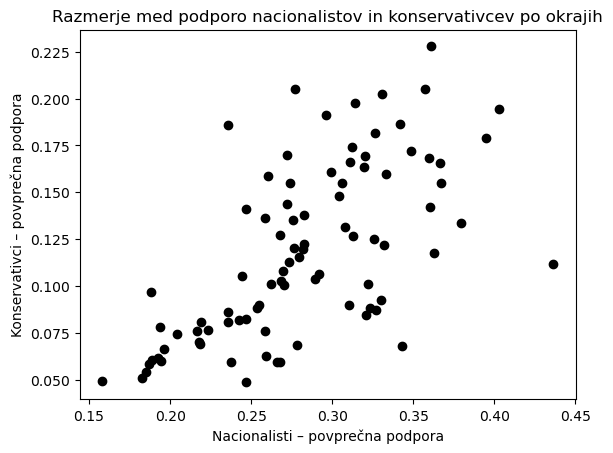

In [30]:
plt.scatter(df_average["NACIONALISTI"], df_average["KONSERVATIVCI"], c="#000000")

plt.xlabel("Nacionalisti – povprečna podpora")
plt.ylabel("Konservativci – povprečna podpora")
plt.title("Razmerje med podporo nacionalistov in konservativcev po okrajih")


Text(0.5, 1.0, 'Razmerje med podporo SD in progresivcev po okrajih')

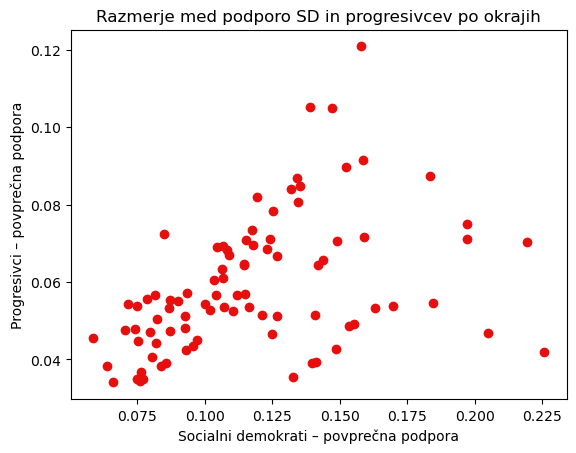

In [31]:
plt.scatter(df_average["SOC.DEM"], df_average["PROGRESIVCI"], c="#e70e0e")

plt.xlabel("Socialni demokrati – povprečna podpora")
plt.ylabel("Progresivci – povprečna podpora")
plt.title("Razmerje med podporo SD in progresivcev po okrajih")


Vidimo, da je korelacija med rezultati SD in progresivcev bistveno manj očitno kot med konservativci in nacionalisti, a je potrebno poudariti, da podrobnejše analize premikanja volilnega telesa med ideologijami ni mogoče trditi nič gotovega.

Ker se slovenski volilni prostor čedalje bolj smatra kot duopol oziroma osredinjen okoli levega konglomerata in nacionalistov, sem preveril še korelacijo med tema dvema ideologijama in rezultat je precej zgovoren.

Text(0.5, 1.0, 'Slovenski politični duopol?')

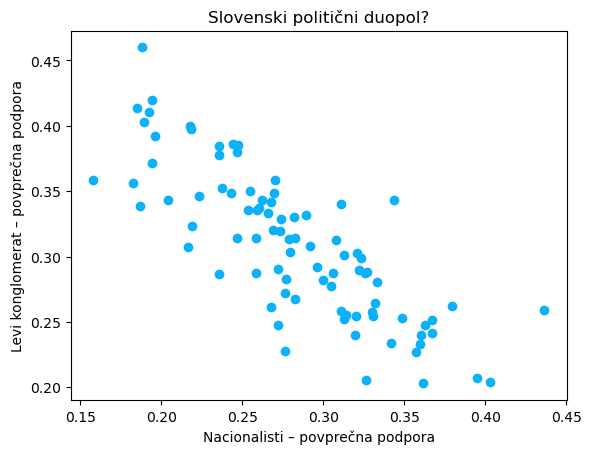

In [32]:
plt.scatter(df_average["NACIONALISTI"], df_average["LEVI KONGLOMERAT"], c="#0CB1F7")

plt.xlabel("Nacionalisti – povprečna podpora")
plt.ylabel("Levi konglomerat – povprečna podpora")
plt.title("Slovenski politični duopol?")

# ZAKLJUČEK
V tej analizi smo na podlagi rezultatov zadnjih 8 državnozborskih volitev analizirali, kateri izmed 88 volilnih okrajev v Sloveniji so najbolj stabilni in kateri najbolj podobni ameriškim "swing state-om". Pogledali smo si, kako se je v teh okrjaih skozi leta spreminjalo razmerje moči med idoelogijami. Pod drobnogled smo vzeli socialno demokracijo in konservativce -- na podalgi spreminjaja oziroma stabilnosti njihovih rezultatov smo izračunali in prikazali, kateri izmed okrajev bi se lahko smatrali kot njihove najtrdnješe baze, kjer je izvolitev v parlament zelo verjetna. Omejili smo se na dve dimenziji: višina povprečnega rezultata ter standardno deviacijo stranke na volitvah v okraju skozi 26 let.

Za konec smo še preverili, ali je očitna kakšna korelacija med ideologijami, ki smo jih proučevali.

Analiza omogoča še kar nekaj bolj zapletenih analitičnih metod. Želel sem si izvesti PCA, ki smo ga letos obravnavali pri Algebri, a je očitno, da tega nek začetnik v pythonu ne zna in bi rezultat bil čisto delo umetne inteligence. 

## PO GLASOVIH

In [50]:
df_average_gl = df_all_gl.groupby('OKRAJ')[ideologije].mean()
df_con_analysis = df_average
df_con_analysis['GLASOVI'] = df_average_gl['KONSERVATIVCI']
df_con_analysis = df_con_analysis[['KONSERVATIVCI', 'GLASOVI']].sort_values('GLASOVI', ascending=False)
df_con_analysis

,KONSERVATIVCI,GLASOVI
OKRAJ,,
1010,0.158471,2840.625
1006,0.171743,2757.250
6006,0.191416,2586.000
6002,0.165711,2567.500
3001,0.160766,2535.750
...,...,...
7011,0.059386,518.375
2004,0.049160,511.875
6010,0.048468,507.750


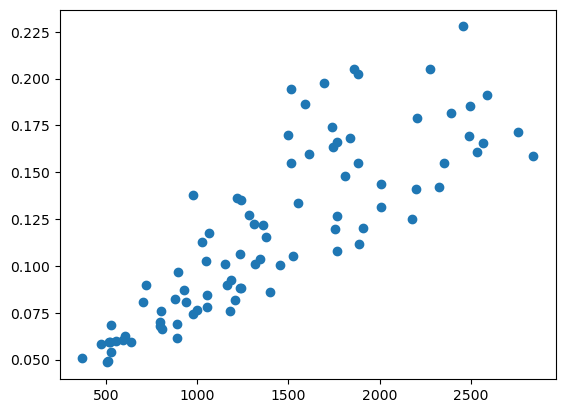

In [51]:
plt.scatter(df_con_analysis['GLASOVI'], df_con_analysis['KONSERVATIVCI'])

In [58]:
df_velikost = round(df_average_gl['KONSERVATIVCI']/df_average['KONSERVATIVCI'])
df_velikost.sort_values(ascending=False)
df_con_analysis['VELIKOST']=df_velikost
df_con_analysis

,KONSERVATIVCI,GLASOVI,VELIKOST
OKRAJ,,,
1010,0.158471,2840.625,17925.0
1006,0.171743,2757.250,16054.0
6006,0.191416,2586.000,13510.0
6002,0.165711,2567.500,15494.0
3001,0.160766,2535.750,15773.0
...,...,...,...
7011,0.059386,518.375,8729.0
2004,0.049160,511.875,10412.0
6010,0.048468,507.750,10476.0


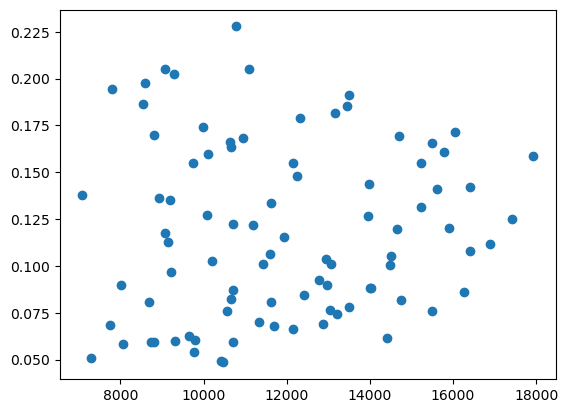

In [60]:
plt.scatter(df_con_analysis['VELIKOST'], df_con_analysis['KONSERVATIVCI'])

# PRINCIPAL COMPONENT ANALYSIS

In [62]:
X=df_all[ideologije]
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
from sklearn.decomposition import PCA

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

In [66]:
import numpy as np

explained = pca.explained_variance_ratio_

for i, variance in enumerate(explained):
    print(f"PC{i+1}: {variance:.2%}")

print()

for i, cumulative in enumerate(np.cumsum(explained)):
    print(f"PC1-PC{i+1}: {cumulative:.2%}")

PC1: 30.04%
PC2: 19.27%
PC3: 15.44%
PC4: 12.37%
PC5: 10.12%
PC6: 7.57%
PC7: 5.16%
PC8: 0.03%

PC1-PC1: 30.04%
PC1-PC2: 49.31%
PC1-PC3: 64.76%
PC1-PC4: 77.13%
PC1-PC5: 87.24%
PC1-PC6: 94.81%
PC1-PC7: 99.97%
PC1-PC8: 100.00%


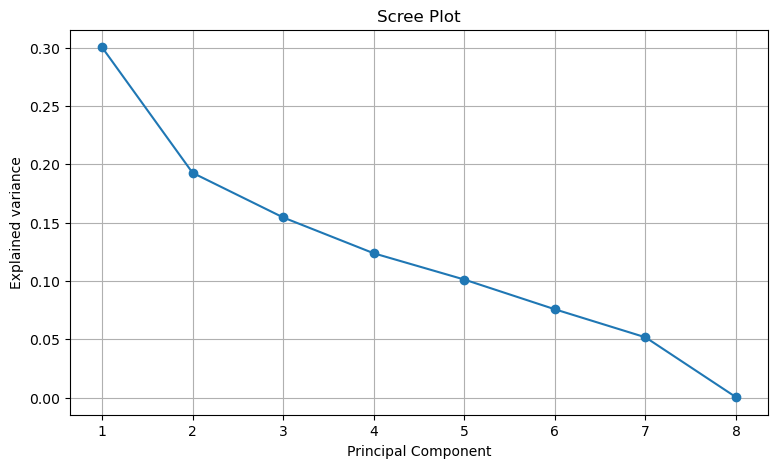

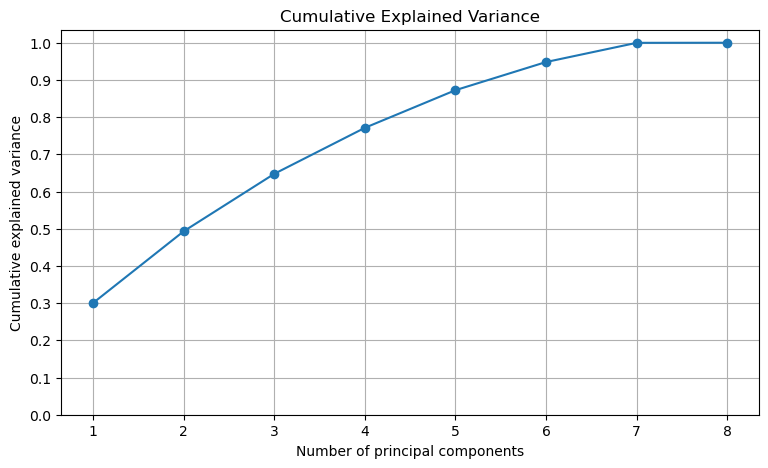

In [69]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.plot(
    range(1, len(explained) + 1),
    explained,
    marker="o"
)

plt.xlabel("Principal Component")
plt.ylabel("Explained variance")
plt.title("Scree Plot")

plt.xticks(range(1, len(explained) + 1))
plt.grid(True)

plt.show()

cumulative = np.cumsum(explained)

plt.figure(figsize=(9, 5))

plt.plot(
    range(1, len(cumulative) + 1),
    cumulative,
    marker="o"
)

plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance")
plt.title("Cumulative Explained Variance")

plt.xticks(range(1, len(cumulative) + 1))
plt.yticks(np.arange(0, 1.1, 0.1))
plt.grid(True)

plt.show()

In [72]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=ideologije,
    columns=[f"PC{i+1}" for i in range(len(ideologije))]
)

print(loadings)

                       PC1       PC2       PC3       PC4       PC5       PC6  \
PROGRESIVCI       0.471881  0.015103  0.007260  0.327873  0.192418 -0.686990   
SOC.DEM          -0.377034  0.196396 -0.569077  0.018296  0.449164  0.145495   
LEVI KONGLOMERAT  0.572702  0.123552 -0.029676 -0.232276 -0.019415  0.253003   
NOVA SREDINA     -0.136436  0.597581  0.199037 -0.098692 -0.597652 -0.021082   
ANTISISTEM        0.260822 -0.512573 -0.211726  0.252733 -0.350914  0.449851   
KONSERVATIVCI    -0.149725 -0.363752  0.593927 -0.449699  0.289518  0.021639   
NACIONALISTI     -0.444387 -0.367008  0.039015  0.324818 -0.338196 -0.286353   
NEUVRŠČENI       -0.025393  0.243086  0.486315  0.675916  0.286923  0.396974   

                       PC7       PC8  
PROGRESIVCI       0.319836 -0.241394  
SOC.DEM           0.230044 -0.468246  
LEVI KONGLOMERAT -0.477065 -0.556718  
NOVA SREDINA      0.370265 -0.283192  
ANTISISTEM        0.468557 -0.124447  
KONSERVATIVCI     0.302556 -0.338317  
NACION

In [78]:
for pc in loadings.columns[:4]:

    print(f"\n===== {pc} =====")

    temp = loadings[pc].sort_values(
        key=abs,
        ascending=False
    )

    for ideology, loading in temp.items():
        print(f"{ideology:20} {loading:+.3f}")


===== PC1 =====
LEVI KONGLOMERAT     +0.573
PROGRESIVCI          +0.472
NACIONALISTI         -0.444
SOC.DEM              -0.377
ANTISISTEM           +0.261
KONSERVATIVCI        -0.150
NOVA SREDINA         -0.136
NEUVRŠČENI           -0.025

===== PC2 =====
NOVA SREDINA         +0.598
ANTISISTEM           -0.513
NACIONALISTI         -0.367
KONSERVATIVCI        -0.364
NEUVRŠČENI           +0.243
SOC.DEM              +0.196
LEVI KONGLOMERAT     +0.124
PROGRESIVCI          +0.015

===== PC3 =====
KONSERVATIVCI        +0.594
SOC.DEM              -0.569
NEUVRŠČENI           +0.486
ANTISISTEM           -0.212
NOVA SREDINA         +0.199
NACIONALISTI         +0.039
LEVI KONGLOMERAT     -0.030
PROGRESIVCI          +0.007

===== PC4 =====
NEUVRŠČENI           +0.676
KONSERVATIVCI        -0.450
PROGRESIVCI          +0.328
NACIONALISTI         +0.325
ANTISISTEM           +0.253
LEVI KONGLOMERAT     -0.232
NOVA SREDINA         -0.099
SOC.DEM              +0.018


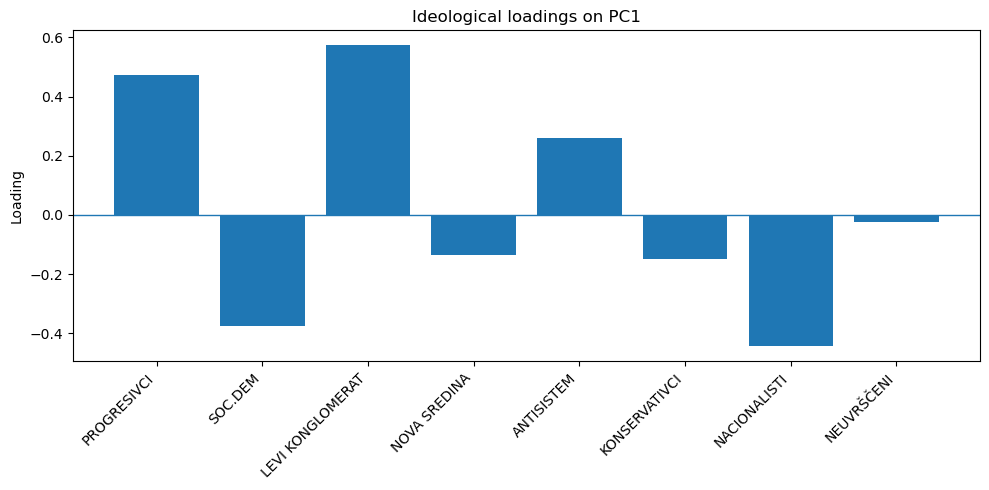

In [79]:
plt.figure(figsize=(10, 5))

plt.bar(
    ideologije,
    loadings["PC1"]
)

plt.axhline(0, linewidth=1)

plt.ylabel("Loading")
plt.title("Ideological loadings on PC1")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

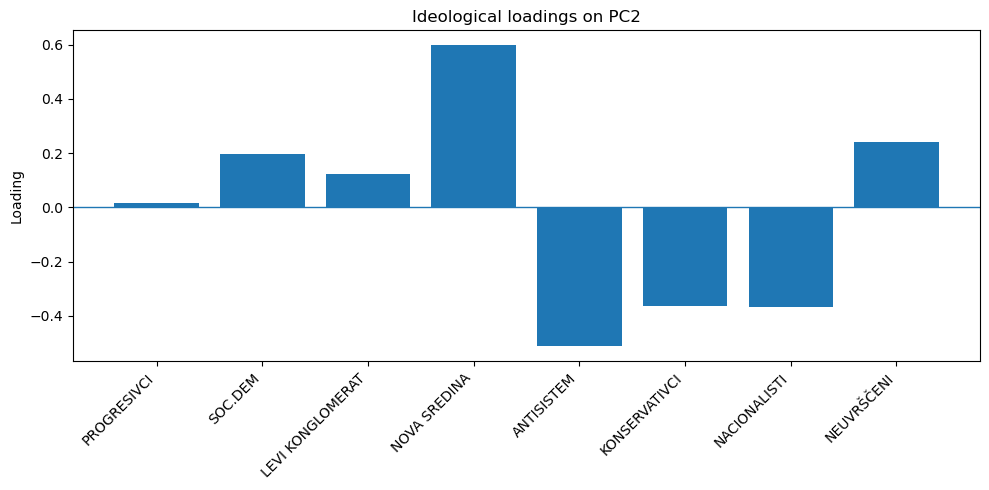

In [80]:
plt.figure(figsize=(10, 5))

plt.bar(
    ideologije,
    loadings["PC2"]
)

plt.axhline(0, linewidth=1)

plt.ylabel("Loading")
plt.title("Ideological loadings on PC2")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [81]:
for i in range(X_pca.shape[1]):
    df_all[f"PC{i+1}"] = X_pca[:, i]

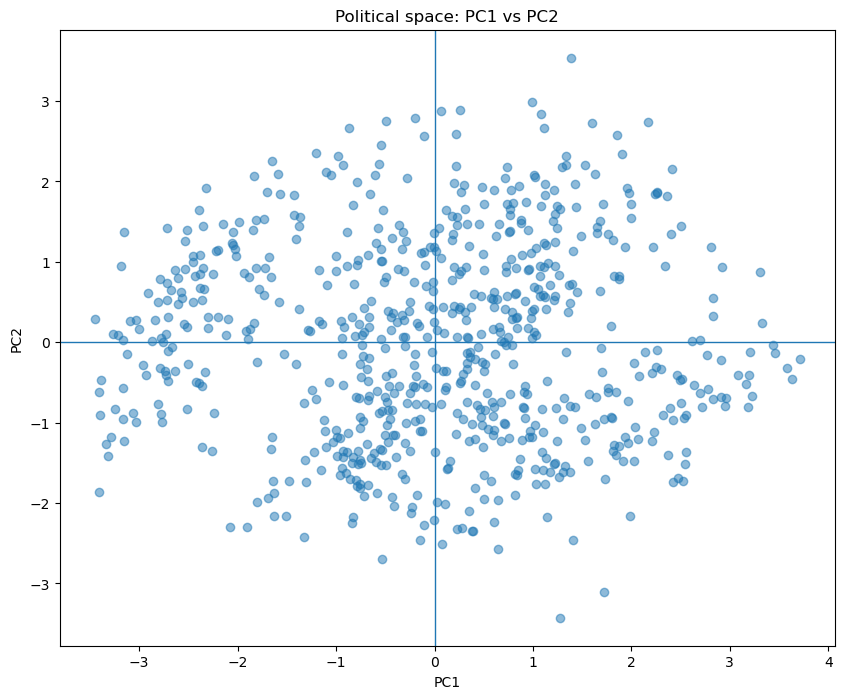

In [82]:
plt.figure(figsize=(10, 8))

plt.scatter(
    df_all["PC1"],
    df_all["PC2"],
    alpha=0.5
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Political space: PC1 vs PC2")

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)

plt.show()

In [83]:
povprecje_leto = (
    df_all
    .groupby("LETO")[["PC1", "PC2", "PC3", "PC4"]]
    .mean()
)

print(povprecje_leto)

           PC1       PC2       PC3       PC4
LETO                                        
2000  0.367200  0.034382  0.421254 -1.250495
2004 -0.675115 -1.131644  0.469132  0.341523
2008 -2.668790  0.159127 -1.597960 -0.103306
2011 -0.862571  1.441072  1.054504  0.216182
2014  0.730021  1.336382  0.111586 -0.865801
2018  0.476967  0.486920  0.512348  1.276109
2022  1.659067 -1.305649 -0.453361 -0.124891
2026  0.973221 -1.020591 -0.517503  0.510679


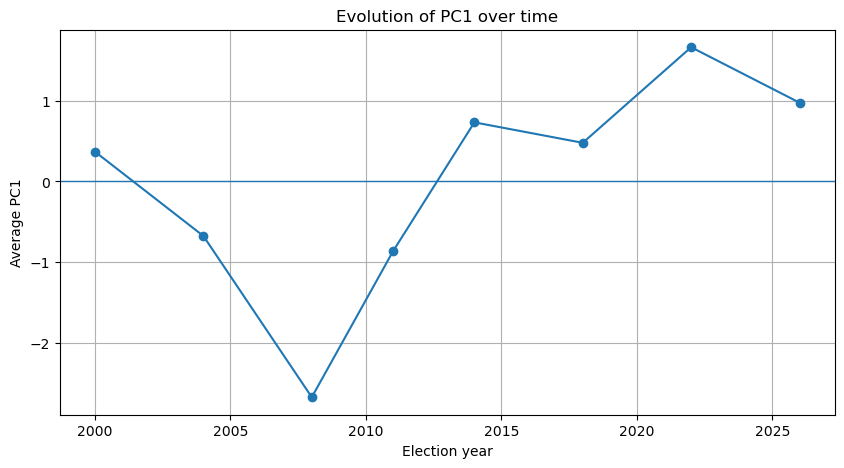

In [84]:
plt.figure(figsize=(10, 5))

plt.plot(
    povprecje_leto.index,
    povprecje_leto["PC1"],
    marker="o"
)

plt.axhline(0, linewidth=1)

plt.xlabel("Election year")
plt.ylabel("Average PC1")
plt.title("Evolution of PC1 over time")

plt.grid(True)

plt.show()

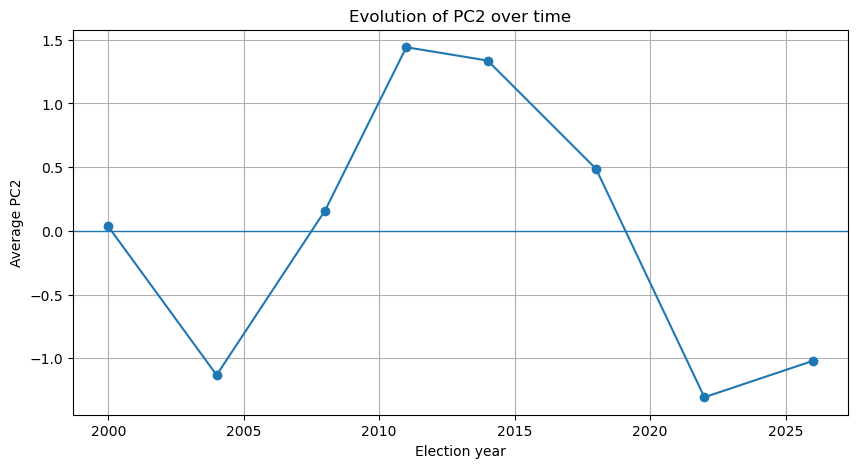

In [85]:
plt.figure(figsize=(10, 5))

plt.plot(
    povprecje_leto.index,
    povprecje_leto["PC2"],
    marker="o"
)

plt.axhline(0, linewidth=1)

plt.xlabel("Election year")
plt.ylabel("Average PC2")
plt.title("Evolution of PC2 over time")

plt.grid(True)

plt.show()

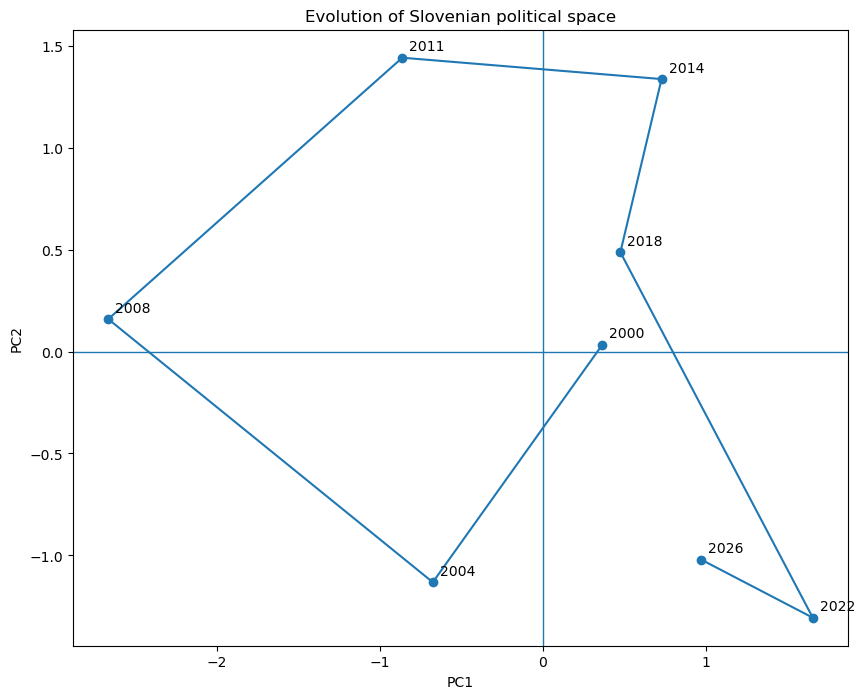

In [86]:
plt.figure(figsize=(10, 8))

plt.plot(
    povprecje_leto["PC1"],
    povprecje_leto["PC2"],
    marker="o"
)

for leto in povprecje_leto.index:

    x = povprecje_leto.loc[leto, "PC1"]
    y = povprecje_leto.loc[leto, "PC2"]

    plt.annotate(
        str(leto),
        (x, y),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("Evolution of Slovenian political space")

plt.show()

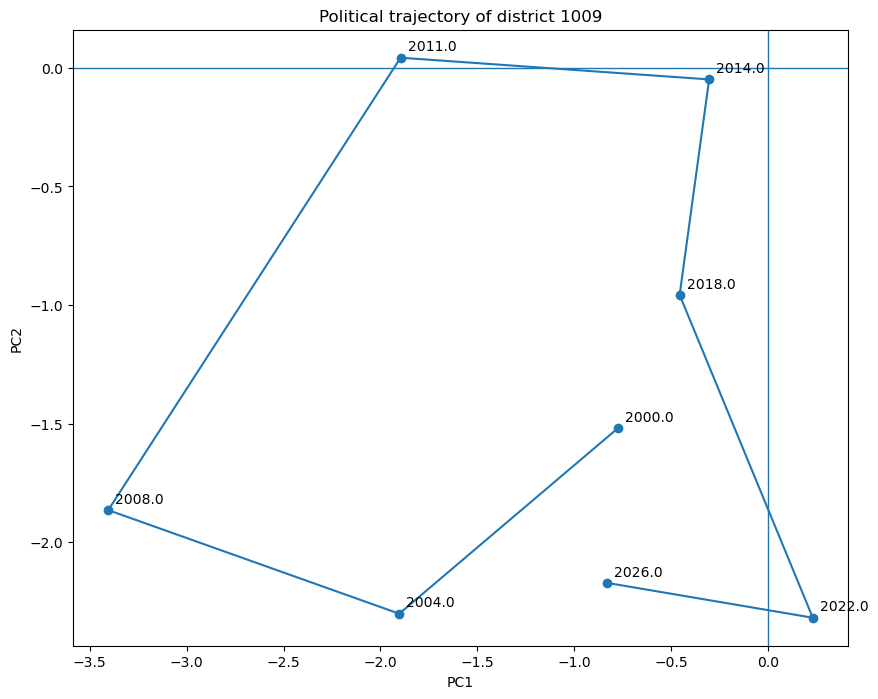

In [88]:
okraj = df_all[df_all["OKRAJ"] == 1009]

plt.figure(figsize=(10, 8))

plt.plot(
    okraj["PC1"],
    okraj["PC2"],
    marker="o"
)

for _, row in okraj.iterrows():

    plt.annotate(
        str(row["LETO"]),
        (row["PC1"], row["PC2"]),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("Political trajectory of district 1009")

plt.show()

            PC1       PC2       PC3       PC4
OKRAJ                                        
1001   0.544538  0.323340 -0.459243  0.362059
1002   0.268630  0.144535  0.201303  0.327568
1003   0.389998  0.037733 -0.036116  0.453114
1004   0.671970  0.124321 -0.412168  0.105936
1005   0.588409 -0.081734 -0.260824  0.092312
...         ...       ...       ...       ...
8007  -0.813991 -0.898081  1.048927  0.014358
8008  -0.701640 -0.325802  0.636477  0.887043
8009  -1.257605 -1.152595  0.868515 -0.102593
8010  -0.332815  0.163718 -0.087759  0.530177
8011  -1.044353 -0.703712  0.788905 -0.158589

[88 rows x 4 columns]


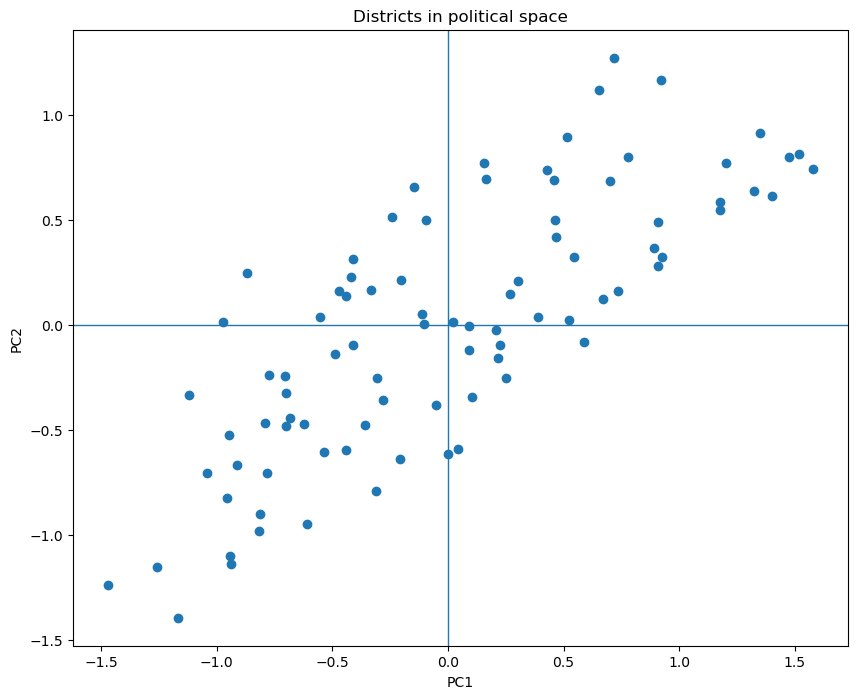

In [89]:
pca_okraji = (
    df_all
    .groupby("OKRAJ")[["PC1", "PC2", "PC3", "PC4"]]
    .mean()
)

print(pca_okraji)

plt.figure(figsize=(10, 8))

plt.scatter(
    pca_okraji["PC1"],
    pca_okraji["PC2"]
)

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("Districts in political space")

plt.show()


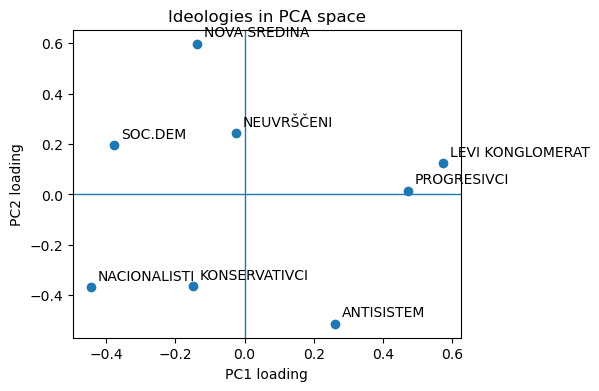

In [91]:
plt.figure(figsize=(5, 4))

plt.scatter(
    loadings["PC1"],
    loadings["PC2"]
)

for ideology in ideologije:

    x = loadings.loc[ideology, "PC1"]
    y = loadings.loc[ideology, "PC2"]

    plt.annotate(
        ideology,
        (x, y),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)

plt.xlabel("PC1 loading")
plt.ylabel("PC2 loading")

plt.title("Ideologies in PCA space")

plt.show()